# 1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")
# Sets the visual style of the plots to a white background with grid lines for better readability

# 2. Load Dataset

In [2]:
# Assuming xlsx file name is 'Pharmaceutical Supply Chain Optimization.xlsx'
df = pd.read_excel('Pharmaceutical Supply Chain Optimization.xlsx')


# View first few rows
df.head()

,Drug,Demand_Forecast,Optimal_Stock_Level,Restocking_Strategy
0,Metformin,7750,4753,Monthly
1,Lisinopril,5136,9965,Quarterly
2,Metformin,3183,2933,Monthly
3,Insulin,2332,3927,Monthly
4,Atorvastatin,3522,6812,Monthly


# 3. Understand Dataset Structure

In [3]:
# Shape of dataset
df.shape

(100000, 4)

In [4]:
# Column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Drug                 100000 non-null  object
 1   Demand_Forecast      100000 non-null  int64 
 2   Optimal_Stock_Level  100000 non-null  int64 
 3   Restocking_Strategy  100000 non-null  object
dtypes: int64(2), object(2)
memory usage: 3.1+ MB


In [5]:
# Statistical summary
df.describe()

,Demand_Forecast,Optimal_Stock_Level
count,100000.000000,100000.000000
mean,5489.372180,6270.155320
std,2597.544993,2744.393068
min,1000.000000,1500.000000
25%,3243.000000,3899.750000
50%,5487.000000,6278.000000
75%,7738.000000,8660.000000
max,9999.000000,10999.000000


# 4. Identify Target Variable
- Target variable: Optimal_Stock_Level
- Features: Drug, Demand_Forecast, Restocking_Strategy

# 5. Check Missing Values

In [6]:
df.isnull().sum()

Drug                   0
Demand_Forecast        0
Optimal_Stock_Level    0
Restocking_Strategy    0
dtype: int64

# 7. Outlier Detection (IQR Method)

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} outliers count:", outliers.shape[0])

Demand_Forecast outliers count: 0
Optimal_Stock_Level outliers count: 0


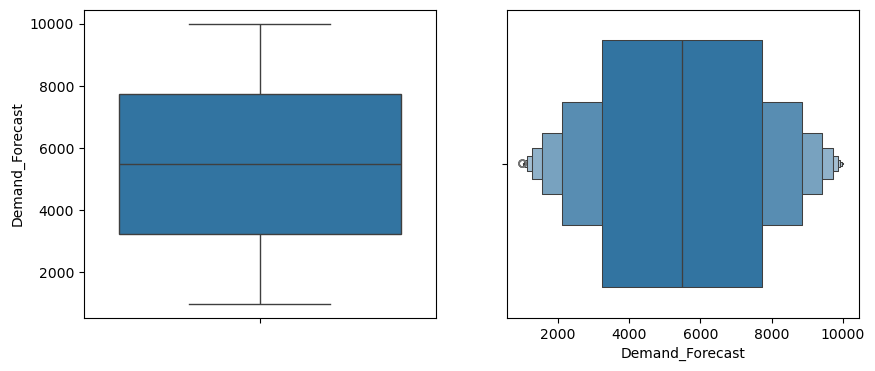

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(y=df['Demand_Forecast'])

plt.subplot(1,2,2)
sns.boxenplot(x=df['Demand_Forecast'])
plt.show()

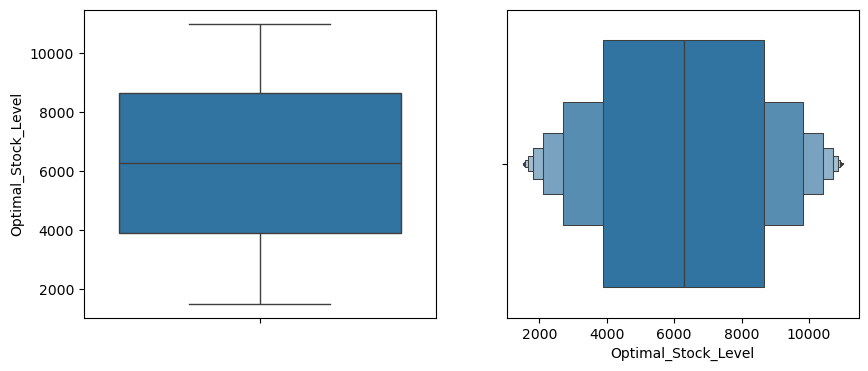

In [9]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(y=df['Optimal_Stock_Level'])

plt.subplot(1,2,2)
sns.boxenplot(x=df['Optimal_Stock_Level'])
plt.show()

# 8. Exploratory Data Analysis (EDA)

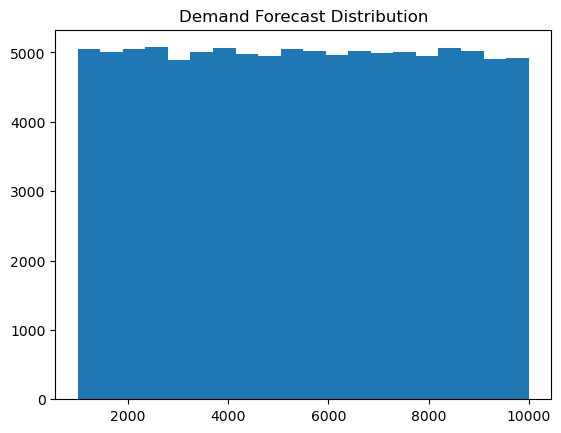

In [10]:
# Distribution of Demand Forecast
plt.figure()
plt.hist(df['Demand_Forecast'], bins=20)
plt.title('Demand Forecast Distribution')
plt.show()

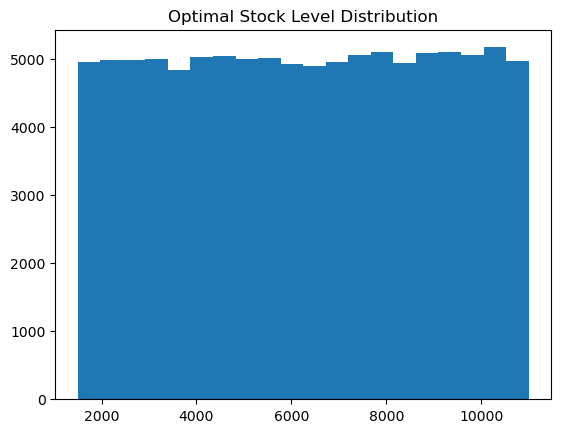

In [11]:
# Distribution of Optimal Stock Level
plt.figure()
plt.hist(df['Optimal_Stock_Level'], bins=20)
plt.title('Optimal Stock Level Distribution')
plt.show()

# 9. Categorical Analysis

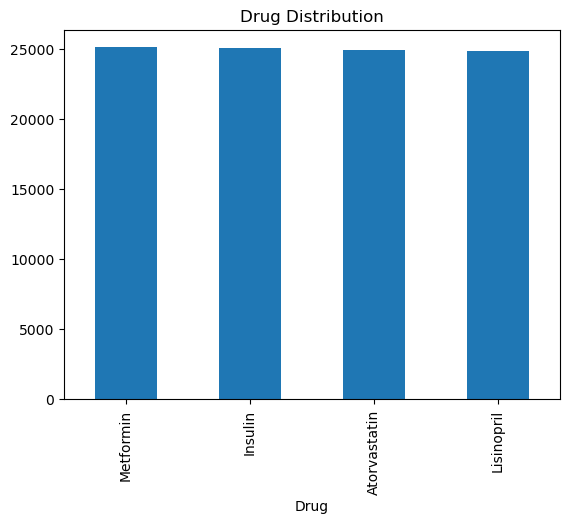

In [12]:
# Drug count
plt.figure()
df['Drug'].value_counts().plot(kind='bar')
plt.title('Drug Distribution')
plt.show()

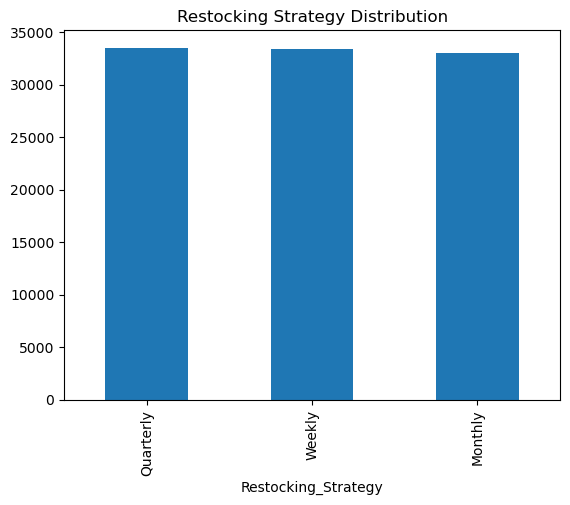

In [13]:
# Restocking Strategy count
plt.figure()
df['Restocking_Strategy'].value_counts().plot(kind='bar')
plt.title('Restocking Strategy Distribution')
plt.show()

# 10. Correlation Analysis

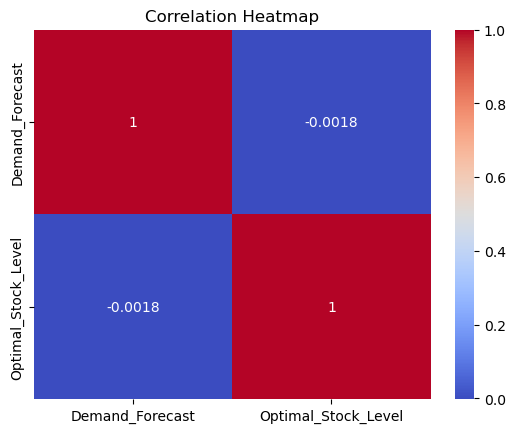

In [14]:
plt.figure()
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 11. Feature Engineering

In [ ]:
# Demand to Stock Ratio
Demand_Stock_Ratio= df['Demand_Forecast'] / df['Optimal_Stock_Level']
Demand_Stock_Ratio

0        1.630549
1        0.515404
2        1.085237
3        0.593838
4        0.517029
           ...   
99995    0.979600
99996    1.154625
99997    1.436865
99998    0.885184
99999    0.255923
Length: 100000, dtype: float64

# 14. Save  Data for Modeling Notebook

In [16]:
df.to_csv('processed_data.csv', index=False)
print(" Processed data saved.")

 Processed data saved.
